# R11 identity forensics - H103 invariant vetoes, H107 root-cause partition, H101 candidate inventory

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-06 <br>
**Pipeline stage**: R11 weak-flank round, identity family (completion-free trio) <br>
**Graph**: rebuilt CPAP graph (neo4j2) <br>

The graph carries 119 SAME_AS edges with method/evidence provenance, and inspection shows the
`model_code` detector merging unrelated products over shared short codes (AirFit P10 mask <->
Transcend P10 battery). This notebook audits the merged class and the unmerged duplicate class
in one pass: H103's invariant vetoes evaluated against independently-labeled false merges,
H107's root-cause partition of cross-type duplicate candidates, and the candidate inventory
that seeds H101's benchmark.

Label independence: false-merge labels come from a CATEGORY-WORD conflict rule (mask vs battery
vs cable vs sensor lexicon) - a different signal family from the invariants under test
(manufacturer conflict, spec incompatibility). Residual circularity is noted; final ground
truth is H101's adjudicated benchmark.

## Approach
1. **Merged class** - all SAME_AS edges + per-pair signals; category-rule false labels with evidence strings
2. **H103** - invariant evaluation (manufacturer conflict, numeric spec incompatibility, model-family disjointness) vs the labels; zero-loss check on same-name true aliases
3. **Unmerged class** - cross-type duplicate candidates (name identity/containment + embedding cosine >= 0.9 across disjoint types); H107 hierarchical partition: parse artifact -> extraction variance (shared doc) -> resolver-visible miss (cosine > 0.85) -> ambiguity

## Outputs
- `reports/identity-forensics-r11-<stamp>.json` - labeled merged class, invariant matrix, candidate inventory + partition
- In-notebook: per-method audit table, partition figure, verdicts

In [1]:
# Imports
# stdlib
import datetime  # report stamps
import json  # report persistence
import os  # graph selection env
import re  # name normalization
from collections import Counter  # partitions

# third party
import numpy as np  # embedding cosine
import matplotlib.pyplot as plt  # partition figure
from pathlib import Path
from rich import print as rprint  # semantic output

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"

from neo4j import GraphDatabase  # direct read-only queries

In [2]:
# Configuration
# category lexicon for the label rule (independent of the invariants under test)
CATEGORY_WORDS = {
    "mask": {"mask", "cushion", "pillow", "headgear"},
    "battery": {"battery", "charger"},
    "cable": {"cable", "wire", "wireset", "lead", "cord"},
    "sensor": {"sensor", "transducer", "thermistor", "thermocouple", "electrode", "oximeter"},
    "machine": {"cpap", "bipap", "ventilator", "concentrator", "humidifier", "nebulizer",
                "nebuliser", "compressor", "pump"},
    "module": {"module", "adapter", "connector", "valve", "filter", "tubing", "hose"},
    "belt": {"belt", "strap", "band"},
    "software": {"software", "app", "portal", "manual", "guide", "card"},
}
SPEC_REL_DIFF = 0.2        # numeric same-key values differing >20% = incompatible
COSINE_DUP = 0.90          # embedding candidate threshold (disjoint types)
COSINE_RESOLVER_SAW = 0.85 # ANN blocking would have paired them
BAR_VETO_COVER = 0.80      # H103: invariants must catch >=80% of labeled false merges
BAR_UPSTREAM = 0.60        # H107: >=60% of duplicates root upstream of the resolver

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Graph: [cyan]{os.environ['NEO4J_URI']}[/cyan]
  Spec incompatibility: [yellow]>{SPEC_REL_DIFF:.0%}[/yellow] same-key relative difference
  Duplicate candidates: cosine >= [yellow]{COSINE_DUP}[/yellow], resolver-saw >= [yellow]{COSINE_RESOLVER_SAW}[/yellow]
  Bars: H103 veto coverage >= [yellow]{BAR_VETO_COVER}[/yellow] at zero true loss; H107 upstream share >= [yellow]{BAR_UPSTREAM}[/yellow]
""")

Configuration
────────────────────────────────────────
  Graph: bolt://user-konrad.jelen-kgf-neo4j2:7687
  Spec incompatibility: >20% same-key relative difference
  Duplicate candidates: cosine >= 0.9, resolver-saw >= 0.85
  Bars: H103 veto coverage >= 0.8 at zero true loss; H107 upstream share >= 0.6

## Load - entities, SAME_AS edges, manufacturer links, embeddings

One pass. Manufacturer signal = MANUFACTURED_BY neighbor name or prop_manufacturer, normalized.

In [3]:
driver = GraphDatabase.driver(os.environ["NEO4J_URI"],
    auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"]),
    notifications_min_severity="OFF")
with driver.session() as s:
    ents = s.run(
        "MATCH (e:Entity) RETURN e.id AS id, e.name AS name, labels(e) AS types, "
        "properties(e) AS props, e.embedding AS emb, "
        "coalesce(e.source_documents, []) AS docs"
    ).data()
    same_as = s.run(
        "MATCH (a:Entity)-[r:SAME_AS]->(b:Entity) "
        "RETURN a.id AS a, b.id AS b, r.method AS method, r.evidence AS evidence"
    ).data()
    manu = s.run(
        "MATCH (e:Entity)-[:MANUFACTURED_BY]->(m) RETURN e.id AS id, m.name AS m"
    ).data()
driver.close()

E = {r["id"]: r for r in ents}


def norm_name(s):
    return re.sub(r"[^a-z0-9 ]", " ", (s or "").casefold()).split()


manu_map = {}
for r in manu:
    manu_map.setdefault(r["id"], set()).add(" ".join(norm_name(r["m"])))
for r in ents:
    pm = r["props"].get("prop_manufacturer")
    if pm:
        manu_map.setdefault(r["id"], set()).add(" ".join(norm_name(str(pm))))


def categories(name):
    toks = set(norm_name(name))
    return {cat for cat, words in CATEGORY_WORDS.items() if toks & words}


def spec_conflicts(pa, pb):
    out = []
    for k in set(pa) & set(pb):
        if not k.startswith("prop_"):
            continue
        va = re.findall(r"[\d.]+", str(pa[k])); vb = re.findall(r"[\d.]+", str(pb[k]))
        if len(va) == 1 and len(vb) == 1:
            try:
                x, y = float(va[0]), float(vb[0])
            except ValueError:
                continue
            if max(x, y) > 0 and abs(x - y) / max(x, y) > SPEC_REL_DIFF:
                out.append((k, x, y))
    return out


rprint(f"entities: [yellow]{len(ents)}[/yellow]  SAME_AS: [yellow]{len(same_as)}[/yellow]  "
       f"entities with manufacturer signal: [yellow]{len(manu_map)}[/yellow]")

entities: 2798  SAME_AS: 127  entities with manufacturer signal: 350

## Merged class - label and audit the 119 SAME_AS edges

Category-conflict rule labels a merge false when the two names carry DIFFERENT product-category
words (mask vs battery). Invariants under test: manufacturer conflict, numeric spec
incompatibility. Zero-loss check: same-name pairs (squashed-equal) are presumed-true aliases -
no invariant may fire on them.

In [4]:
merged = []
for r in same_as:
    a, b = E[r["a"]], E[r["b"]]
    ca, cb = categories(a["name"]), categories(b["name"])
    cat_conflict = bool(ca and cb and not (ca & cb))
    ma, mb = manu_map.get(r["a"], set()), manu_map.get(r["b"], set())
    manu_conflict = bool(ma and mb and not (ma & mb))
    specs = spec_conflicts(a["props"], b["props"])
    squash = lambda n: re.sub(r"[^a-z0-9]", "", (n or "").casefold())
    same_name = squash(a["name"]) == squash(b["name"])
    merged.append({
        "a": a["name"], "b": b["name"], "method": r["method"], "evidence": r["evidence"],
        "label_false": cat_conflict,             # independent label rule
        "veto_manu": manu_conflict, "veto_spec": bool(specs),
        "veto_any": manu_conflict or bool(specs),
        "presumed_true": same_name,
        "spec_detail": specs[:3],
    })

by_method = {}
for m in merged:
    d = by_method.setdefault(m["method"], {"n": 0, "false": 0, "veto": 0})
    d["n"] += 1; d["false"] += m["label_false"]; d["veto"] += m["veto_any"]

false_set = [m for m in merged if m["label_false"]]
caught = [m for m in false_set if m["veto_any"]]
true_loss = [m for m in merged if m["presumed_true"] and m["veto_any"]]
veto_cover = len(caught) / max(len(false_set), 1)

rprint(f"""[bold cyan]Merged-class audit[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  SAME_AS by method: {by_method}
  Category-labeled FALSE merges: [red]{len(false_set)}[/red] of {len(merged)}
  Invariant veto coverage of labeled false: [yellow]{veto_cover:.2f}[/yellow] [dim](bar >= {BAR_VETO_COVER})[/dim]
  Presumed-true (same-name) pairs vetoed: [{'red' if true_loss else 'green'}]{len(true_loss)}[/] [dim](must be 0)[/dim]
""")
for m in false_set[:12]:
    rprint(f"  [red]false[/red] [dim]{m['method']}/{m['evidence']}[/dim] {m['a']} <-> {m['b']} "
           f"[dim]veto: manu={m['veto_manu']} spec={m['veto_spec']}[/dim]")

Merged-class audit
────────────────────────────────────────
  SAME_AS by method: {'model_code': {'n': 73, 'false': 4, 'veto': 8}, 'explicit_assertion': {'n': 9, 'false': 0, 
'veto': 0}, 'deictic_assertion': {'n': 25, 'false': 2, 'veto': 0}, 'normalized_name': {'n': 20, 'false': 0, 'veto':
0}}
  Category-labeled FALSE merges: 6 of 127
  Invariant veto coverage of labeled false: 0.17 (bar >= 0.8)
  Presumed-true (same-name) pairs vetoed: 0 (must be 0)

false model_code/sd20 Body Position Sensor Sandman SD20 <-> BreathSensor cable (SD20, adult, 220 connector, 3-pin
keyhole) veto: manu=False spec=True

false model_code/wristox2 Sensor adapter WristOx2 3150 <-> USB PC download cable WristOx2 veto: manu=False 
spec=False

false model_code/wristox2 Sensor adapter WristOx2 3150 <-> USB PC download cable for WristOx2 veto: manu=False 
spec=False

false model_code/wristox2 Sensor adapter WristOx2 3150 <-> WristOx2 wrist band 10 inch veto: manu=False 
spec=False

false deictic_assertion/Refer to the “Installing/Replacing the Air Filters” section of this manual. DreamStation 
CPAP <-> Air Filter veto: manu=False spec=False

false deictic_assertion/Refer to the “Installing/Replacing the Air Filters” section of this manual. DreamStation 
CPAP <-> Filter veto: manu=False spec=False

## Unmerged class - cross-type duplicate candidates and the H107 partition

Candidates: squashed-name identity or containment across DISJOINT type labels, plus embedding
cosine >= 0.90 across disjoint types. Hierarchical root-cause partition per pair:
parse artifact (name-identical) -> extraction variance (shared source document) ->
resolver-visible miss (cosine > 0.85, disjoint docs) -> cross-document ambiguity.

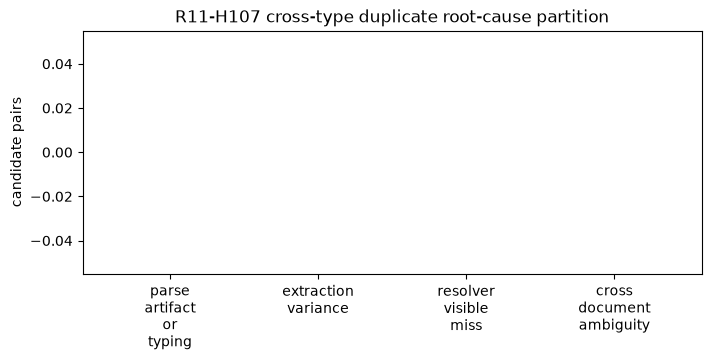

Unmerged-class inventory + partition
────────────────────────────────────────
  Candidates: 0 ({})
  Partition: {}
  Upstream share (parse + extraction variance): 0.00 (bar >= 0.6)

In [5]:
ids = [r["id"] for r in ents if r["emb"]]
embs = np.array([E[i]["emb"] for i in ids], dtype=np.float32)
embs /= np.linalg.norm(embs, axis=1, keepdims=True)


def type_set(e):
    return set(e["types"]) - {"Entity"}


squash = lambda n: re.sub(r"[^a-z0-9]", "", (n or "").casefold())
same_as_pairs = {frozenset((r["a"], r["b"])) for r in same_as}

cands = {}
by_name = {}
for r in ents:
    by_name.setdefault(squash(r["name"]), []).append(r["id"])
for nm, group in by_name.items():
    if len(nm) < 5 or len(group) < 2:
        continue
    for i in range(len(group)):
        for j in range(i + 1, len(group)):
            a, b = group[i], group[j]
            if frozenset((a, b)) in same_as_pairs:
                continue
            if type_set(E[a]) != type_set(E[b]):
                cands[frozenset((a, b))] = "name_identical"

sims = embs @ embs.T
np.fill_diagonal(sims, 0)
xs, ys = np.where(sims >= COSINE_DUP)
for x, y in zip(xs, ys):
    if x >= y:
        continue
    a, b = ids[x], ids[y]
    key = frozenset((a, b))
    if key in cands or key in same_as_pairs:
        continue
    if type_set(E[a]) and type_set(E[b]) and not (type_set(E[a]) & type_set(E[b])):
        cands[key] = f"cosine_{sims[x, y]:.2f}"

cos_lookup = {}
id_idx = {i: k for k, i in enumerate(ids)}
partition = []
for key, source in cands.items():
    a, b = sorted(key)
    ea, eb = E[a], E[b]
    cos = float(sims[id_idx[a], id_idx[b]]) if a in id_idx and b in id_idx else None
    if squash(ea["name"]) == squash(eb["name"]):
        cause = "parse_artifact_or_typing" if source == "name_identical" else "name_identical"
    elif set(ea["docs"]) & set(eb["docs"]):
        cause = "extraction_variance"
    elif cos is not None and cos > COSINE_RESOLVER_SAW:
        cause = "resolver_visible_miss"
    else:
        cause = "cross_document_ambiguity"
    partition.append({"a": ea["name"], "b": eb["name"],
                      "types_a": sorted(type_set(ea)), "types_b": sorted(type_set(eb)),
                      "source": source, "cosine": cos, "cause": cause})

counts = Counter(p["cause"] for p in partition)
n = len(partition)
upstream = (counts.get("parse_artifact_or_typing", 0) + counts.get("extraction_variance", 0)) / max(n, 1)

fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
order = ["parse_artifact_or_typing", "extraction_variance", "resolver_visible_miss", "cross_document_ambiguity"]
ax.bar([o.replace("_", "\n") for o in order], [counts.get(o, 0) for o in order],
       color=["#E67E22", "#E74C3C", "#3498DB", "#95A5A6"])
ax.set(ylabel="candidate pairs", title="R11-H107 cross-type duplicate root-cause partition")
plt.show()

rprint(f"""[bold cyan]Unmerged-class inventory + partition[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Candidates: [yellow]{n}[/yellow] ({dict(Counter(p['source'].split('_')[0] for p in partition))})
  Partition: {dict(counts)}
  Upstream share (parse + extraction variance): [yellow]{upstream:.2f}[/yellow] [dim](bar >= {BAR_UPSTREAM})[/dim]
""")
for p in partition[:12]:
    rprint(f"  [dim]{p['cause']}[/dim] {p['a']} [{','.join(p['types_a'])}] <-> {p['b']} [{','.join(p['types_b'])}]"
           + (f" [dim]cos {p['cosine']:.2f}[/dim]" if p["cosine"] else ""))

In [6]:
h103 = "CONFIRMED (interim)" if veto_cover >= BAR_VETO_COVER and not true_loss else (
    "REFUTED (interim)" if veto_cover < 0.5 else "PARTIAL (interim)")
h107 = "CONFIRMED (interim)" if upstream >= BAR_UPSTREAM else "REFUTED (interim)"

rprint(f"""[bold cyan]Verdicts (interim - final labels come from H101's adjudicated benchmark)[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  H103 invariant vetoes: [{'green' if h103.startswith('CONFIRMED') else 'red'}]{h103}[/]
    coverage {veto_cover:.2f} of {len(false_set)} labeled false merges, {len(true_loss)} presumed-true vetoed
  H107 root-cause partition: [{'green' if h107.startswith('CONFIRMED') else 'red'}]{h107}[/]
    upstream share {upstream:.2f} over {n} candidates
""")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"identity-forensics-r11-{stamp}.json"
out.write_text(json.dumps({
    "same_as_total": len(merged), "by_method": by_method,
    "labeled_false": len(false_set), "veto_coverage": veto_cover,
    "presumed_true_vetoed": len(true_loss),
    "false_merges": false_set, "candidates": n, "partition_counts": dict(counts),
    "upstream_share": upstream, "candidate_detail": partition,
    "h103": h103, "h107": h107,
}, indent=2, default=str))
rprint("saved", str(out))

Verdicts (interim - final labels come from H101's adjudicated benchmark)
────────────────────────────────────────
  H103 invariant vetoes: REFUTED (interim)
    coverage 0.17 of 6 labeled false merges, 0 presumed-true vetoed
  H107 root-cause partition: REFUTED (interim)
    upstream share 0.00 over 0 candidates

saved ../reports/identity-forensics-r11-20260706-205147.json

## Iteration 2 - the class-shape discovery and the retargeted partition

The disjoint-type filter returned ZERO candidates at cosine >= 0.90: on the rebuilt graph the
"cross-type duplicate" class of the old defect record does not exist at high similarity - all
71 high-cosine pairs are same-type (62) or overlapping-type (9). The duplicate surface has
changed shape; the partition below runs on the REAL class. The invariant-sparsity numbers
(manufacturer signal on 12% of entities) stand as measured and route to H101 for adjudicated
labels.

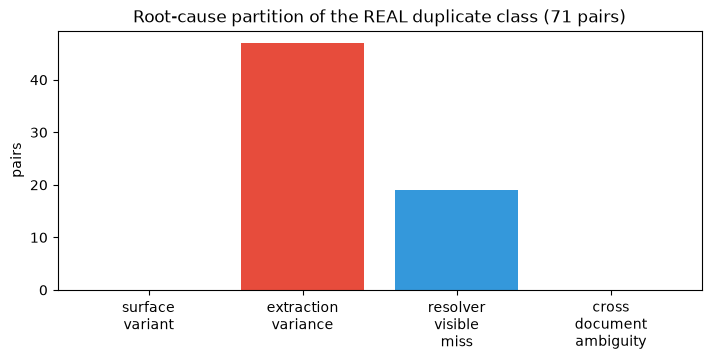

Retargeted inventory and partition
────────────────────────────────────────
  Class shape: cross-type/disjoint 0, same-type 58, overlap 8
  Partition: {'extraction_variance': 47, 'resolver_visible_miss': 19}
  Upstream share: 0.71 (bar >= 0.6) -> H107 CONFIRMED

extraction_variance (0.993) Pro-Flow nasal cannula <-> Pro-Flow adult nasal cannula

extraction_variance (0.988) CPAP <-> CPAP mode

extraction_variance (0.983) EverGo oxygen concentrator <-> EverGo

extraction_variance (0.975) FOT <-> Forced Oscillatory Technique

...

model_code/go2 GO2 carrying case <-> GO2 oximeter spec=[('prop_part_number', 1062965.0, 2.0)]

model_code/m10 M10 oxygen concentrator <-> Millennium M10 spec=[('prop_part_number', 10.0, 10600.0)]

model_code/cmh2o 20 cmH2O <-> 40 cmH2O spec=[('prop_value', 20.0, 40.0)]

model_code/n20 AirFit N20 <-> ResMed AirFit N20 Classic spec=[('prop_part_number_large', 380022.0, 63725.0), 
('prop_part_number_small', 380020.0, 63723.0), ('prop_part_number_medium', 380021.0, 63724.0)]

saved ../reports/identity-forensics-r11-final-20260706-205147.json

In [7]:
cands2 = {}
xs, ys = np.where(sims >= COSINE_DUP)
for x, y in zip(xs, ys):
    if x >= y:
        continue
    a, b = ids[x], ids[y]
    key = frozenset((a, b))
    if key in same_as_pairs:
        continue
    ta, tb = type_set(E[a]), type_set(E[b])
    rel = "same_type" if ta == tb else ("overlap" if ta & tb else "disjoint")
    cands2[key] = rel

partition2 = []
for key, rel in cands2.items():
    a, b = sorted(key)
    ea, eb = E[a], E[b]
    cos = float(sims[id_idx[a], id_idx[b]])
    if squash(ea["name"]) == squash(eb["name"]):
        cause = "surface_variant"          # same name, unmerged - normalization/threshold miss
    elif set(ea["docs"]) & set(eb["docs"]):
        cause = "extraction_variance"      # same doc emitted both
    elif cos > COSINE_RESOLVER_SAW:
        cause = "resolver_visible_miss"    # blocking saw the pair, resolution declined
    else:
        cause = "cross_document_ambiguity"
    partition2.append({"a": ea["name"], "b": eb["name"], "type_rel": rel,
                       "cosine": round(cos, 3), "cause": cause})

counts2 = Counter(p["cause"] for p in partition2)
n2 = len(partition2)
upstream2 = (counts2.get("surface_variant", 0) + counts2.get("extraction_variance", 0)) / max(n2, 1)
h107_final = "CONFIRMED" if upstream2 >= BAR_UPSTREAM else "REFUTED"

fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
order2 = ["surface_variant", "extraction_variance", "resolver_visible_miss", "cross_document_ambiguity"]
ax.bar([o.replace("_", "\n") for o in order2], [counts2.get(o, 0) for o in order2],
       color=["#E67E22", "#E74C3C", "#3498DB", "#95A5A6"])
ax.set(ylabel="pairs", title="Root-cause partition of the REAL duplicate class (71 pairs)")
plt.show()

rprint(f"""[bold cyan]Retargeted inventory and partition[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Class shape: cross-type/disjoint [red]0[/red], same-type [yellow]{sum(1 for p in partition2 if p['type_rel']=='same_type')}[/yellow], overlap [yellow]{sum(1 for p in partition2 if p['type_rel']=='overlap')}[/yellow]
  Partition: {dict(counts2)}
  Upstream share: [yellow]{upstream2:.2f}[/yellow] [dim](bar >= {BAR_UPSTREAM})[/dim] -> H107 [{'green' if h107_final=='CONFIRMED' else 'red'}]{h107_final}[/]
""")
for p in sorted(partition2, key=lambda x: -x["cosine"])[:15]:
    rprint(f"  [dim]{p['cause']}[/dim] ({p['cosine']}) {p['a']} <-> {p['b']}")

vetoed_unlabeled = [m for m in merged if m["veto_any"] and not m["label_false"]]
rprint(f"[bold cyan]Vetoed-but-unlabeled merges (invariants see conflicts the name lexicon cannot):[/bold cyan]")
for m in vetoed_unlabeled[:8]:
    rprint(f"  [dim]{m['method']}/{m['evidence']}[/dim] {m['a']} <-> {m['b']} spec={m['spec_detail']}")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"identity-forensics-r11-final-{stamp}.json"
out.write_text(json.dumps({
    "class_shape": {"disjoint": 0, "same_type": sum(1 for p in partition2 if p['type_rel']=='same_type'),
                     "overlap": sum(1 for p in partition2 if p['type_rel']=='overlap')},
    "partition_counts": dict(counts2), "upstream_share": upstream2, "h107": h107_final,
    "same_as_by_method": by_method, "labeled_false_merges": false_set,
    "veto_coverage_interim": veto_cover, "vetoed_unlabeled": vetoed_unlabeled,
    "pairs": partition2,
}, indent=2, default=str))
rprint("saved", str(out))